# Homework 1: From Pixels to a Project
**AI Research and Design Forum · NCSSM · Pranava Kumar**

**Target: about 60 minutes. Due: before our next meeting.**

This week, make a small model, change something meaningful, and explain what happened. Then tell me what you would like to work on in the forum. You do not need previous machine-learning experience or a polished project idea.

**Your job:** run the examples, change `K_TO_TRY`, replace the example in `my_feature`, and fill in the **Your response** cells. The supplied code runs before you edit it; the final test stays paused until you explicitly unlock it.

This is the **8 × 8 scikit-learn digits dataset used in our slides, not MNIST**. It is our common practice exercise, not a commitment to a dataset-based final project. [1, 2]

**Plan:** setup 5 min; A: inspect 5 min; B: neighbors 7 min; C: compare models 10 min; D: make a feature 12 min; E: final check 6 min; F: project directions 15 min. Extensions are optional. If you reach an hour while stuck, save your progress, describe the blocker, and complete Part F rather than spending another hour debugging.

## Start here · 5 minutes
Open this `.ipynb` file in **Google Colab** using **File → Upload notebook**, or in a Jupyter environment you already use. Colab supports importing existing notebooks. [3] A CPU is enough for this exercise; do not request a GPU.

Run code cells from top to bottom using the play button or **Shift + Enter**. Double-click a text cell to edit your answers. Save a personal copy named `Lastname_Firstname_HW1.ipynb`. Do not run the final-test cell until you reach Part E.

**A tiny Python guide:** `=` gives a value a name; `#` starts a comment; `[0]` selects the first item; `.shape` tells you an array's dimensions; `.mean()` computes an average; `def` defines a reusable function; a `for` loop repeats an action. You do not need to memorize every line.

You may ask a classmate or an AI tool to explain code or help debug. Describe the help you used, and write the interpretations yourself. Do not upload private information or API keys.

In [4]:
# Run this first. These are the libraries used throughout the notebook.
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

print("Ready. scikit-learn version:", sklearn.__version__)
# If an import fails in a local notebook, run this in a NEW code cell:
# %pip install numpy matplotlib scikit-learn
# Then restart the kernel and run this cell again.

Ready. scikit-learn version: 1.9.1


## A. What is the model actually seeing? · 5 minutes
An **example** is one handwritten-digit image. A **feature** is a number we supply to the model. A **label** is the answer attached to the example: the digit from 0 to 9. The built-in dataset contains 1,797 images, each with 64 pixel values ranging from 0 to 16. [1, 2]

We separate the images before exploring them. About 60% are for **training** (examples available to learn from), 20% for **validation** (comparing our choices), and 20% for the **test** (checking the final choice). The fixed random seed keeps the split the same when you rerun; stratification keeps the digit proportions similar across the sets. [1, 4]

The split code is provided. You are not expected to write it yourself today. Look only at training examples for now.

In [5]:
digits = load_digits()
images = digits.images.astype(float)
labels = digits.target
indices = np.arange(len(labels))

# First hold out 20%; then hold out 25% of the remaining 80% (=20% total).
trainval_idx, test_idx = train_test_split(
    indices, test_size=0.20, random_state=42, stratify=labels
)
train_idx, val_idx = train_test_split(
    trainval_idx, test_size=0.25, random_state=42,
    stratify=labels[trainval_idx]
)

I_train, I_val = images[train_idx], images[val_idx]
y_train, y_val = labels[train_idx], labels[val_idx]
assert not (set(train_idx) & set(val_idx))
assert not (set(train_idx) & set(test_idx))
assert not (set(val_idx) & set(test_idx))
print("Training:", len(train_idx), "Validation:", len(val_idx), "Test:", len(test_idx))
print("Training image array shape:", I_train.shape)

Training: 1077 Validation: 360 Test: 360
Training image array shape: (1077, 8, 8)


Image shape: (8, 8)
Flattened feature vector shape: (64,)
Label: 3
Mean pixel intensity: 5.406


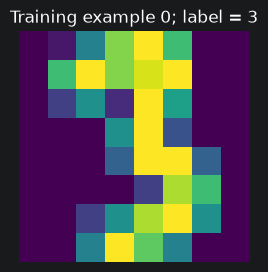

In [6]:
# Change 0 to 1 or 2 and rerun to inspect a different TRAINING image.
EXAMPLE = 0
image = I_train[EXAMPLE]
print("Image shape:", image.shape)
print("Flattened feature vector shape:", image.reshape(-1).shape)
print("Label:", y_train[EXAMPLE])
print("Mean pixel intensity:", round(float(image.mean()), 3))
plt.figure(figsize=(3, 3))
plt.imshow(image, vmin=0, vmax=16, interpolation="nearest")
plt.title(f"Training example {EXAMPLE}; label = {y_train[EXAMPLE]}")
plt.axis("off")
plt.show()

### Your response A
**In your own words, what is a feature here, and what is the label?**

*Write here.*

**Could two different digits have similar average pixel intensity? What information does that average leave out?**

*Write here.*

## B. Understand one k-nearest-neighbors prediction · 7 minutes
**k-nearest neighbors (kNN)** predicts a label by finding the `k` closest training examples and taking their most common label. Each neighbor gets one vote in this exercise. There are no neural-network weights to train: the training examples are stored for later comparisons. [1, 5]

Use the five points from our slides. The new point is **(3, 3)**.

| Training point | Label |
|---|---|
| (2, 3) | A |
| (3, 5) | B |
| (5, 4) | A |
| (1, 1) | B |
| (6, 5) | B |

Squared distance is `(x1 - z1)**2 + (x2 - z2)**2`. For example, the squared distance from (3, 3) to (2, 3) is **1**. Taking square roots would not change the ordering.

**Before running the next cell**, calculate the other four squared distances and predict the answers for `k = 1, 3, 5`. Then change `K_TO_TRY` to check each prediction. Read the three numbered steps in the code; you do not have to recreate the function from memory.

### Your response B
**Other four squared distances, in table order:** ...

**Predictions before running:** k = 1: ...; k = 3: ...; k = 5: ...

**Explain one prediction using the neighbors' labels. Why can changing k change the result?**

*Write here.*

In [14]:
def knn_one(query, train_X, train_y, k):
    """A small teaching implementation for one query and comparable feature scales."""
    if not isinstance(k, int) or not 1 <= k <= len(train_y):
        raise ValueError("k must be an integer from 1 to the number of training examples.")
# 1. Compute one squared distance per training example.
    squared_distances = np.sum((train_X - query) ** 2, axis=1)
    # 2. Keep the k closest. Equal distances retain training-row order.
    nearest = np.argsort(squared_distances, kind="stable")[:k]
    # 3. Count the votes and choose the most common label.
    names, counts = np.unique(train_y[nearest], return_counts=True)
    # np.unique sorts labels; a vote tie therefore goes to the first sorted label.
    prediction = names[np.argmax(counts)]
    return prediction, nearest, squared_distances

points = np.array([[2, 3], [3, 5], [5, 4], [1, 1], [6, 5]], dtype=float)
point_labels = np.array(["A", "B", "A", "B", "B"])
K_TO_TRY = 5  # YOUR TURN: also try 1 and 5.
prediction, nearest, distances = knn_one(
    np.array([3, 3]), points, point_labels, K_TO_TRY
)
print("Squared distances in table order:", distances)
print("Nearest labels:", point_labels[nearest])
print("Prediction:", prediction)

Squared distances in table order: [ 1.  4.  5.  8. 13.]
Nearest labels: ['A' 'B' 'A' 'B' 'B']
Prediction: B


## C. Build a baseline and compare kNN models · 10 minutes
Now use scikit-learn to apply the same idea to digit images. **`fit(X, y)`** gives the classifier its training examples. **`predict(X)`** produces labels. **`score(X, y)`** reports accuracy here: correct predictions divided by all predictions. `X` is a table with one example per row and one feature per column. [5]

First use a **majority-class baseline**: always predict the most common *training* label, ignoring the pixels. This gives our model something concrete to improve on. [1, 6]

Then compare `k = 1, 3, 5, 9`. Keep the same split and the same 64 pixel features for every model. We divide every pixel by the known constant 16, not by a statistic estimated from the full dataset. This common rescaling does not change the ordering of Euclidean distances.

**Before running:** do you expect larger k to always improve validation accuracy? Make a guess, then check it.

In [15]:
def pixel_features(batch):
    # Flatten each 8 x 8 image to 64 features; put pixel values on a 0-to-1 scale.
    return batch.reshape(len(batch), 64) / 16.0

X_train_pixels = pixel_features(I_train)
X_val_pixels = pixel_features(I_val)

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_pixels, y_train)
baseline_val_accuracy = baseline.score(X_val_pixels, y_val)
print(f"Majority baseline validation accuracy: {baseline_val_accuracy:.1%}")

pixel_models = {}
pixel_scores = {}
for k in [1, 3, 5, 9]:
    model = KNeighborsClassifier(n_neighbors=k, weights="uniform", metric="euclidean")
    model.fit(X_train_pixels, y_train)
    pixel_models[k] = model
    pixel_scores[k] = model.score(X_val_pixels, y_val)
    print(f"64 pixels | k = {k} | validation accuracy = {pixel_scores[k]:.1%}")

# For a tie, keep the first k in the fixed order above.
best_k = max(pixel_scores, key=pixel_scores.get)
print("Selected pixel-model k:", best_k)
print("First five validation predictions:", pixel_models[best_k].predict(X_val_pixels[:5]))

Majority baseline validation accuracy: 10.3%
64 pixels | k = 1 | validation accuracy = 98.9%
64 pixels | k = 3 | validation accuracy = 98.1%
64 pixels | k = 5 | validation accuracy = 98.1%
64 pixels | k = 9 | validation accuracy = 97.5%
Selected pixel-model k: 1
First five validation predictions: [9 4 2 8 1]


### Your response C
**My guess before running; what happened instead or as expected:** ...

**Majority baseline validation accuracy:** ...

**Validation accuracies:** k = 1: ...; k = 3: ...; k = 5: ...; k = 9: ...

**Selected k and its validation accuracy:** ...

**Why are we choosing k using validation results rather than trying every k on the test set?**

*Write here.*

## D. Make a feature, then find out whether it helps · 12 minutes
A feature is a **measurement**, not a guessed answer. For example, `image.mean()` summarizes average pixel intensity. You can also measure *where* the ink is.

The provided example measures average intensity in the central 4 × 4 square:
```python
image[2:6, 2:6].mean()
```
Indices start at 0. In `image[rows, columns]`, `2:6` means positions 2, 3, 4, 5; `:` by itself means all positions.

**Your task:** change `my_feature` to measure something different and give it a matching `FEATURE_NAME`. Choose one of these starting points or invent your own:

| Measurement | Expression to put inside `float(...)` |
|---|---|
| Mean intensity in the top half | `image[:4, :].mean()` |
| Top intensity minus bottom intensity | `image[:4, :].mean() - image[4:, :].mean()` |
| Fraction of pixels above intensity 8 | `(image > 8).mean()` |

You may use these expressions directly. The learning task is to explain, run, and test your choice. Use only the image, never its label or its row number. Return one finite number per image.

**Before running:** write what your feature measures and why it might distinguish digits that have similar overall averages. Predict its value on a blank image (all zeros) and a solid image (all 16s). A feature may legitimately have the same value on both.

### Your response D — before the experiment
**My feature, in plain English:** ...

**Why it might help beyond the mean alone:** ...

**Expected value on a blank image / a solid image:** ... / ...

In [9]:
FEATURE_NAME = "center intensity (provided example)"  # YOUR TURN: rename this.

def my_feature(image):
    """Return one measurement from an 8 x 8 image, without using the label."""
    # YOUR TURN: replace the center example with your chosen measurement.- Changed
    return float(image[1:3, 1:3].mean())

def mean_features(batch):
    # Shape (number of images, 1): one mean-intensity feature per image.
    return batch.mean(axis=(1, 2)).reshape(-1, 1)

def custom_features(batch):
    # Shape (number of images, 2): mean intensity, then your new feature.
    means = batch.mean(axis=(1, 2))
    extra = np.array([my_feature(img) for img in batch], dtype=float)
    if extra.shape != (len(batch),) or not np.isfinite(extra).all():
        raise ValueError("my_feature must return one finite number for each image.")
    return np.column_stack([means, extra])

print("Feature:", FEATURE_NAME)
print("Blank image:", my_feature(np.zeros((8, 8))))
print("Solid image:", my_feature(np.full((8, 8), 16.0)))
print("One training image [mean, new feature]:", custom_features(I_train[:1])[0])

Feature: center intensity (provided example)
Blank image: 0.0
Solid image: 16.0
One training image [mean, new feature]: [5.40625 7.3125 ]


### Use the feature in an actual model
Compare **mean intensity alone** against **mean intensity plus your feature**, using `k = 3` in both. This tests adding your measurement while holding the model rule, k, and data split fixed. We also print the 64-pixel model at the same k for context.

The two summary-feature models use `StandardScaler`: it subtracts each feature's training mean and divides by its training standard deviation (with a safe convention for constant features). A pipeline learns those values on training data and reuses them on validation data. This matters when, for example, one measurement is a fraction and another has a much larger numerical range. Do not fit a new scaler on validation or test data. [7, 8]

The 64-pixel model keeps its existing constant division by 16. Your two-number summary may be much worse than 64 pixels. That is a useful result, not a failed homework assignment.

In [10]:
mean_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=3, weights="uniform", metric="euclidean")
)
custom_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=3, weights="uniform", metric="euclidean")
)
mean_model.fit(mean_features(I_train), y_train)
custom_model.fit(custom_features(I_train), y_train)
mean_val_accuracy = mean_model.score(mean_features(I_val), y_val)
custom_val_accuracy = custom_model.score(custom_features(I_val), y_val)

print("FEATURE COMPARISON — same split, k = 3 throughout")
print(f"64 pixels:                  {pixel_scores[3]:.1%}")
print(f"Mean only (1 feature):       {mean_val_accuracy:.1%}")
print(f"Mean + my feature (2):       {custom_val_accuracy:.1%}")
print(f"Change from adding feature: {100 * (custom_val_accuracy - mean_val_accuracy):+.1f} percentage points")

FEATURE COMPARISON — same split, k = 3 throughout
64 pixels:                  98.1%
Mean only (1 feature):       13.1%
Mean + my feature (2):       26.7%
Change from adding feature: +13.6 percentage points


### Your response D — after the experiment
**Did the blank/solid checks match your definition?** ...

**Validation accuracy: mean only / mean + my feature / 64 pixels at k = 3:** ... / ... / ...

**Did adding your feature help on this split? State what changed, what stayed fixed, and one limitation of the comparison.**

*Write here. A single split does not establish that your feature is always better.*

### Optional extension — do this before the final test, not after
Choose at most one. This is not required for completion.

**See why scale matters:** make copies of your two-feature training and validation arrays, then multiply their second columns by 100. Do not edit `my_feature` again or overwrite the required models. Compare kNN with and without a scaler, keeping k and the split fixed. Predict which procedure should resist this change of units, apart from numerical/tie effects.

**Go one step deeper into kNN:** use `knn_one` on one validation digit and the 64-pixel training features; inspect the selected training neighbors. For ten digit classes, an odd k does not eliminate every possible vote tie.

Keep extension results in a new cell and label them exploratory. The required final comparison below uses the original three feature choices.

## E. Lock your choice; then check it · 6 minutes
Select among the best pixel model from Part C, mean-only kNN, and mean-plus-your-feature kNN, using **validation accuracy only**. The next cell lists those choices and suggests the highest-scoring one. For a tie, it keeps the first listed option.

Write your commitment below. Then change `READY_FOR_FINAL_TEST` to `True` and run the final-test cell. You must finish feature editing and any extensions first. **Do not tune the model after seeing its test result.** Rerunning the same unchanged notebook for reproducibility is fine. [1, 8]

In [16]:
fitted_models = {
    "pixels": pixel_models[best_k],
    "mean": mean_model,
    "custom": custom_model,
}
feature_functions = {
    "pixels": pixel_features,
    "mean": mean_features,
    "custom": custom_features,
}
validation_scores = {
    "pixels": pixel_scores[best_k],
    "mean": mean_val_accuracy,
    "custom": custom_val_accuracy,
}
selected_ks = {"pixels": best_k, "mean": 3, "custom": 3}
for name, score in validation_scores.items():
    print(f"{name:8s} | k = {selected_ks[name]} | validation accuracy = {score:.1%}")
suggested_choice = max(validation_scores, key=validation_scores.get)
print("Suggested choice:", suggested_choice)

FINAL_CHOICE = suggested_choice
READY_FOR_FINAL_TEST = True  # Change to True ONLY after writing your commitment.

pixels   | k = 1 | validation accuracy = 98.9%
mean     | k = 3 | validation accuracy = 13.1%
custom   | k = 3 | validation accuracy = 26.7%
Suggested choice: pixels


### Your response E — commitment before the test
**My chosen features and k:** ...

**Validation accuracy and reason for this choice:** ...

Final choice: pixels; k = 1
Test accuracy: 98.6% (355/360 correct)
Majority baseline test accuracy: 10.0%
Number of mistakes: 5


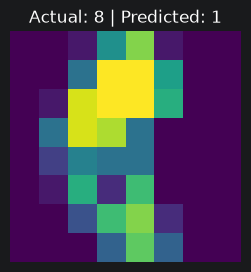

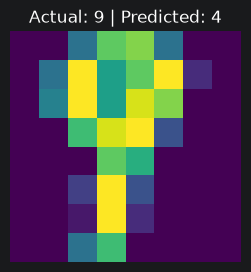

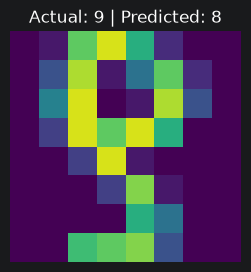

In [17]:
if not READY_FOR_FINAL_TEST:
    print("PAUSED: finish Parts A-D and write your commitment before unlocking the test.")
else:
    if FINAL_CHOICE not in fitted_models:
        raise ValueError("FINAL_CHOICE must be 'pixels', 'mean', or 'custom'.")
    # No fitting occurs here. All models and scalers remain trained on training data only.
    I_test = images[test_idx]
    y_test = labels[test_idx]
    final_model = fitted_models[FINAL_CHOICE]
    final_predictions = final_model.predict(feature_functions[FINAL_CHOICE](I_test))
    test_accuracy = float(np.mean(final_predictions == y_test))
    baseline_test_accuracy = baseline.score(pixel_features(I_test), y_test)
    print(f"Final choice: {FINAL_CHOICE}; k = {selected_ks[FINAL_CHOICE]}")
    print(f"Test accuracy: {test_accuracy:.1%} ({np.sum(final_predictions == y_test)}/{len(y_test)} correct)")
    print(f"Majority baseline test accuracy: {baseline_test_accuracy:.1%}")
    mistakes = np.flatnonzero(final_predictions != y_test)
    print("Number of mistakes:", len(mistakes))
    if len(mistakes) == 0:
        print("No mistakes on this split; this does not establish perfect real-world performance.")
    for j in mistakes[:3]:
        plt.figure(figsize=(3, 3))
        plt.imshow(I_test[j], vmin=0, vmax=16, interpolation="nearest")
        plt.title(f"Actual: {y_test[j]} | Predicted: {final_predictions[j]}")
        plt.axis("off")
        plt.show()

### Your response E — after the test
**Final model / baseline test accuracy:** ... / ...

**Describe one displayed mistake. What about the image could explain the confusion?** If there are no mistakes, say so and describe an untested setting instead.

*Write here.*

**Finish this sentence:** “These results show ..., but they do not show ... .”

*Write here. This random image split does not establish performance on entirely new writers, photographs, or whiteboards; those would need an appropriate evaluation.*

## F. What do you actually want to do? · 15 minutes
This is an interest check, not a binding project proposal. I want to learn what excites you, what you already know, and how to help you start. **“I'm not sure yet” is a valid answer.**

### Your response F1 — starting point and preferences
**Name:** ... Atul Nitin

**Python / ML experience:** New to Python / some Python / comfortable coding / already doing ML. Add one sentence if useful.
Already doing ML

**What would you like to do? Select any and elaborate briefly:**
- [-] Work with an existing public dataset.
- [-] Collect or create my own data or examples.
- [ ] Avoid a dataset-centered project; focus on an AI tool, system, theory, or evaluation.
- [ ] Continue a project I have already started.
- [ ] Build an app or explore a startup idea.
- [-] Reproduce a paper or investigate a research question.
- [-] Learn the foundations before choosing a project.
- [-] Join a suggested project / find teammates / I am not sure yet.

**What interests you about that direction?** ...
I love logic but don't want to be all larp with the project or app before understanding the topics foremost.

**Solo or team preference; any topic or teammate preferences:** ... Both are fine. Akshar's my roommate so he's prbly a good person for me to work with

A project does not have to begin with downloading a dataset or training a model. But you will still need a way to check it: hand-written test cases, example tasks, a mathematical argument, a comparison with a simple alternative, or feedback gathered with appropriate permission.

### Your response F2 — three small possibilities
Write **three one-sentence ideas or questions**. They may be rough. For an existing project, three possible improvements or experiments are enough. You do not have to claim an idea is new or find a dataset this week.

**Possibility 1:** ... I want to learn how to create a model that can deal with non-binary categorical data without using 1-2-3-4 or smth similar. A true form of breaking up data possibilities independently for data that isn't linear where one category isn't between to others. Ex: pet is not between human and dragon

**Possibility 2:** ... I want to be able to handle data around me like water quality and see patterns.

**Possibility 3:** ... I want to be able to create a model that can handle input data that isn't purely numerical.

### Your response F3 — make one idea small enough to start
Choose the one you are most curious about. Short phrases are fine; aim for about **100-150 words total**.

**I want to build or investigate ... for / because ...**
I want to investigate various logical paths for AI because I like logic.

*Write here. Name a specific problem, user, or question rather than just “an AI app.”*
We could try refining the end of weighted KNN, we could try to refine normalization for a given dataset to perfect the output, anything!
**What already exists, if anything? What would be new work for this forum?**
Weighted KNN is a thing, we could try modifying it to be better.
*Write here. An existing project is welcome; separate past work from the next contribution.*

**My first small artifact in the next two weeks could be ...**
Test results
*Examples: one comparison notebook, a simple interface, a labeled set of test prompts, or a visual demonstration. Not an entire company or a finished paper.*
A notebook
**I would check whether it works by ... and compare it with ...**
I would run error function on my data, compare it to standard weighted KNN
*Name a measurement or concrete check: accuracy, correct answers on fixed questions, time to finish a task, specific behaviors, or mathematical correctness. Include a simple baseline or alternative. For a startup idea, state whose problem you are testing.*
Error Value
**My data, examples, or other evidence would come from ...**
Any dataset
*“No downloaded dataset; I will write ten test cases” is acceptable. Use public/permitted material; do not put private student information into a shared notebook.*

**My next action is ... ; I would need help with ...**
I will try messing around with KNN.

*Examples: Python, the math, finding suitable data, narrowing the question, teammates, or evaluation.*

### Two examples of a manageable direction — illustrations, not assigned projects
**Dataset-based:** “I want to test whether coarse summaries of digit images preserve enough information for classification. My first artifact would compare pixel features with regional averages on a fixed validation split.”

**Tool/startup, without a downloaded ML dataset:** “I want to help club members find event information. My first artifact would be a tiny question-answering demo over approved public event pages. I would write ten questions with known answers and compare correctness and lookup time with a simple keyword search. I need help deciding whether AI adds anything.”

## Before submitting
Submit **one notebook** with your answers, saved outputs, feature code, comparison results, final test result, and project directions. Both the experiment and Part F belong in this file. Keep your interpretations individual even if you worked with someone else. If you cannot run the code, submit the written sections and the exact error or a screenshot of it; do not invent results.

**Help or collaboration used:** ...

**One question or blocker to bring to our next meeting:** ...

**What counts as good work:** you can explain features and neighbors; you changed and tested a measurement; you kept validation and test roles separate; and your proposed next step is concrete. A thoughtful negative result counts. You do not need the highest accuracy or the most ambitious idea.

## Sources and further help
The digit activity follows the forum slides; the custom-feature exercise, response prompts, and project-interest form are new scaffolding for Homework 1. The project directions extend the slides' open project choices and early question-development plan. You do not need to read all of these sources to complete the homework.

1. Pranava Kumar, *AI Research and Design: An Introduction and Plans for the Forum* (2026-2027), PDF pp. 5-13 (features, neighbors, evaluation, first project), pp. 14-16 and 19 (projects and questions), p. 18 (working with data).
2. scikit-learn, [load_digits](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html). Original dataset credited in the slides to E. Alpaydin and C. Kaynak.
3. Google Colab, [Frequently asked questions](https://research.google.com/colaboratory/faq.html).
4. scikit-learn, [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).
5. scikit-learn, [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html).
6. scikit-learn, [DummyClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html).
7. scikit-learn, [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).
8. scikit-learn, [Common pitfalls and recommended practices](https://scikit-learn.org/stable/common_pitfalls.html).